In [37]:
import pandas as pd

import seaborn as sns
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc


In [38]:
# prompt: read the data set /data set.csv
df = pd.read_csv('data set.csv')


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


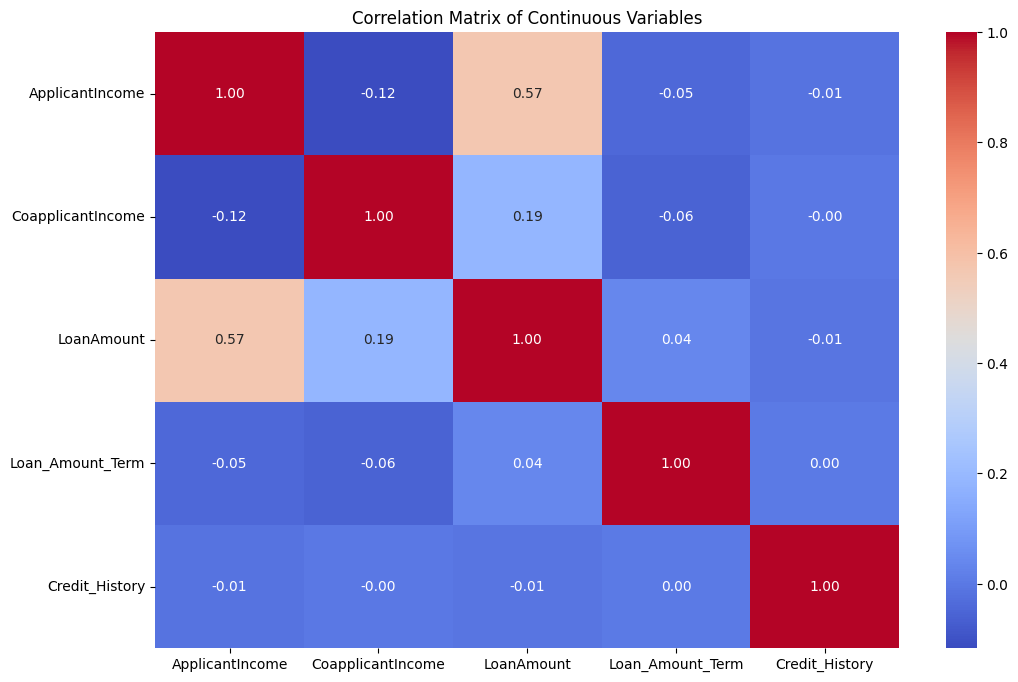

In [40]:
# prompt: generate a code for correlation on this data set

# Correlation Matrix for Continuous Variables
continuous_features = df.select_dtypes(include=['number']).columns
correlation_matrix = df[continuous_features].corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.show()


In [41]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [42]:
# Begin data cleaning and imputation

# Step 1: Imputation for categorical columns using mode
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 2: Imputation for numerical columns using median for LoanAmount and mode for Loan_Amount_Term, Credit_History already handled
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Verify that the dataset has no more missing values
missing_values_after_imputation = df.isnull().sum()

# Display cleaned data summary and check for any remaining missing values
df.info(), missing_values_after_imputation


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


<ipython-input-42-2ef397e304df>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
<ipython-input-42-2ef397e304df>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

(None,
 Loan_ID              0
 Gender               0
 Married              0
 Dependents           0
 Education            0
 Self_Employed        0
 ApplicantIncome      0
 CoapplicantIncome    0
 LoanAmount           0
 Loan_Amount_Term     0
 Credit_History       0
 Property_Area        0
 Loan_Status          0
 dtype: int64)

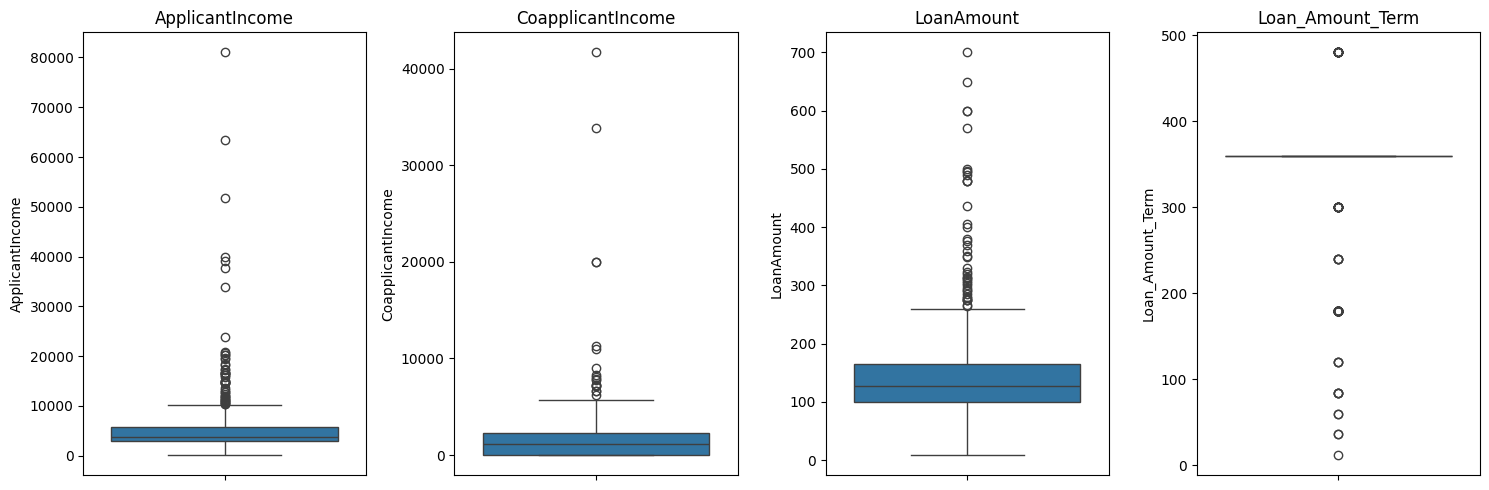

In [43]:
# prompt: check for outlier in ApplicantIncome , CoapplicantIncome , LoanAmount  , Loan_Amount_Term use box plot

import matplotlib.pyplot as plt

# Create box plots for the specified columns
plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
sns.boxplot(y='ApplicantIncome', data=df)
plt.title('ApplicantIncome')

plt.subplot(1, 4, 2)
sns.boxplot(y='CoapplicantIncome', data=df)
plt.title('CoapplicantIncome')

plt.subplot(1, 4, 3)
sns.boxplot(y='LoanAmount', data=df)
plt.title('LoanAmount')

plt.subplot(1, 4, 4)
sns.boxplot(y='Loan_Amount_Term', data=df)
plt.title('Loan_Amount_Term')

plt.tight_layout()
plt.show()


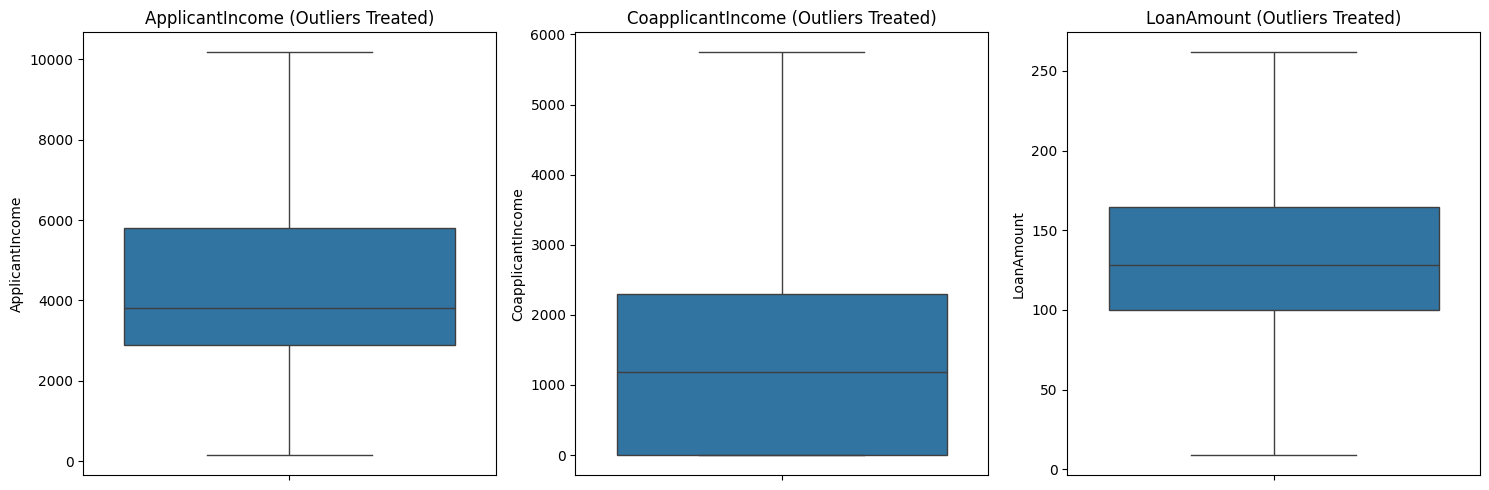

In [44]:
# prompt: treat outliers

# Define a function to treat outliers using IQR method
def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower_bound, upper_bound)
    return df


# Apply the function to the columns with outliers
df = treat_outliers_iqr(df, 'ApplicantIncome')
df = treat_outliers_iqr(df, 'CoapplicantIncome')
df = treat_outliers_iqr(df, 'LoanAmount')


# Plot the box plots again to see the effect of outlier treatment
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y='ApplicantIncome', data=df)
plt.title('ApplicantIncome (Outliers Treated)')

plt.subplot(1, 3, 2)
sns.boxplot(y='CoapplicantIncome', data=df)
plt.title('CoapplicantIncome (Outliers Treated)')

plt.subplot(1, 3, 3)
sns.boxplot(y='LoanAmount', data=df)
plt.title('LoanAmount (Outliers Treated)')

plt.tight_layout()
plt.show()


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    float64
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(5), object(8)
memory usage: 62.5+ KB


In [46]:
# prompt: do lable encoding in Gender , Married , Dependents  , Education , Self_Employed , Property_Area , Loan_Status

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply label encoding to the specified columns
for column in ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
  df[column] = le.fit_transform(df[column])

df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


In [47]:
# prompt: drop Loan_ID

df = df.drop('Loan_ID', axis=1)


In [48]:
# prompt: split data into train and test in .7 and .3 respectively

from sklearn.model_selection import train_test_split

# Assuming 'Loan_Status' is your target variable
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


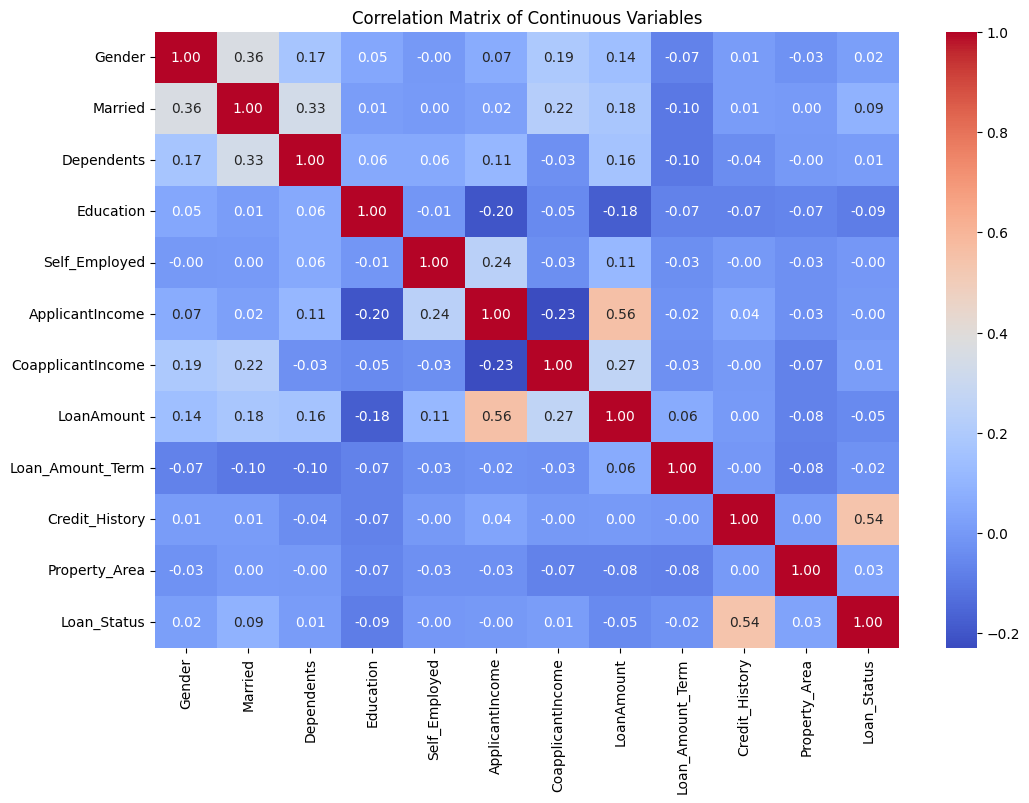

In [49]:
# prompt: generate a code for correlation on this data set

# Correlation Matrix for Continuous Variables
continuous_features = df.select_dtypes(include=['number']).columns
correlation_matrix = df[continuous_features].corr()

# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.show()

In [63]:
# prompt: list the least correalted variables  with loan status

# Calculate the correlation of all features with 'Loan_Status'
correlation_with_loan_status = df.corr()['Loan_Status'].sort_values()

# Display the least correlated variables with Loan_Status
least_correlated_variables = correlation_with_loan_status[abs(correlation_with_loan_status) < 0.1]
print("Least correlated variables with Loan_Status:")
print(least_correlated_variables)


Least correlated variables with Loan_Status:
Education           -0.085884
LoanAmount          -0.047262
Loan_Amount_Term    -0.022549
Self_Employed       -0.003700
ApplicantIncome     -0.000442
Dependents           0.010118
CoapplicantIncome    0.011983
Gender               0.017987
Property_Area        0.032112
Married              0.091478
Name: Loan_Status, dtype: float64


In [50]:
X_train

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
553,1,1,0,1,0,2454.00,2333.0,181.0,360.0,0.0,2
601,1,1,0,1,0,2894.00,2792.0,155.0,360.0,1.0,0
261,1,0,0,0,0,2060.00,2209.0,134.0,360.0,1.0,1
496,1,1,0,1,0,2600.00,1700.0,107.0,360.0,1.0,0
529,1,0,0,1,0,6783.00,0.0,130.0,360.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
71,1,1,2,1,1,1875.00,1875.0,97.0,360.0,1.0,1
106,1,1,2,0,0,10171.25,1126.0,225.0,360.0,1.0,2
270,0,0,0,0,0,3237.00,0.0,30.0,360.0,1.0,2
435,0,1,0,0,0,10047.00,0.0,128.0,240.0,1.0,1


In [51]:
y_train

,Loan_Status
553,0
601,1
261,1
496,1
529,1
...,...
71,1
106,1
270,1
435,1


In [52]:
X_test

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
350,1,1,0,0,0,9083.00,0.0,228.0,360.0,1.0,1
377,1,1,0,0,0,4310.00,0.0,130.0,360.0,1.0,1
163,1,1,2,0,0,4167.00,1447.0,158.0,360.0,1.0,0
609,0,0,0,0,0,2900.00,0.0,71.0,360.0,1.0,0
132,1,0,0,0,0,2718.00,0.0,70.0,360.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...
380,1,1,0,0,0,3333.00,2500.0,128.0,360.0,1.0,1
446,1,1,2,1,0,4652.00,0.0,110.0,360.0,1.0,0
144,1,1,2,0,0,10171.25,0.0,187.0,180.0,1.0,2
290,1,1,0,0,0,3075.00,2416.0,139.0,360.0,1.0,0


In [53]:
y_train

,Loan_Status
553,0
601,1
261,1
496,1
529,1
...,...
71,1
106,1
270,1
435,1


In [54]:
# prompt: run logistic regression on this

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a logistic regression model
model = LogisticRegression()

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)

# Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7837837837837838

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix:
[[ 27  38]
 [  2 118]]


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
# prompt: run a significance test and give summary output

from scipy import stats

# Assuming you want to test the significance of the relationship between LoanAmount and Loan_Status
# You can replace 'LoanAmount' and 'Loan_Status' with other relevant variables for your analysis

# Perform a t-test to compare the means of LoanAmount for different Loan_Status groups
loan_approved = df[df['Loan_Status'] == 1]['LoanAmount']
loan_rejected = df[df['Loan_Status'] == 0]['LoanAmount']

t_statistic, p_value = stats.ttest_ind(loan_approved, loan_rejected)

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Interpret the results:
alpha = 0.05  # Significance level
if p_value < alpha:
    print("The difference in LoanAmount between loan approved and rejected groups is statistically significant.")
else:
    print("The difference in LoanAmount between loan approved and rejected groups is not statistically significant.")

# You can also perform other tests like ANOVA or Chi-square depending on the nature of your variables
# and research question.


# Summary output:
print("\nSummary Output:")
print("----------------")
print("Significance Test: Independent Samples T-test")
print("Variables: LoanAmount and Loan_Status")
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")
print(f"Significance Level (alpha): {alpha}")
if p_value < alpha:
    print("Conclusion: There is a statistically significant difference in LoanAmount between loan approved and rejected groups.")
else:
    print("Conclusion: There is no statistically significant difference in LoanAmount between loan approved and rejected groups.")



T-statistic: -1.1705127803025461
P-value: 0.2422502569478031
The difference in LoanAmount between loan approved and rejected groups is not statistically significant.

Summary Output:
----------------
Significance Test: Independent Samples T-test
Variables: LoanAmount and Loan_Status
T-statistic: -1.1705127803025461
P-value: 0.2422502569478031
Significance Level (alpha): 0.05
Conclusion: There is no statistically significant difference in LoanAmount between loan approved and rejected groups.


In [56]:
# prompt: give summary output for logistics regression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming you have X_train, y_train, X_test, y_test, and the model defined and trained in previous cells
# If not, please define and train the model as shown in your original code

# Make predictions on the testing data (if not already done)
# y_pred = model.predict(X_test)

# Evaluate the model's performance (if not already done)
# accuracy = accuracy_score(y_test, y_pred)

# Summary output for Logistic Regression
print("\nSummary Output for Logistic Regression:")
print("---------------------------------------")
# print("Accuracy: {accuracy}") # This line might cause error if accuracy is not defined
try:
    print(f"Accuracy: {accuracy}")  # Try printing accuracy if it exists
except NameError:
    print("Accuracy: Not Calculated (y_test or y_pred might be missing)")
print("\nClassification Report:")
try:
    print(classification_report(y_test, y_pred))  # Try printing classification report if y_test and y_pred exist
except NameError:
    print("Classification Report: Not Calculated (y_test or y_pred might be missing)")
print("\nConfusion Matrix:")
try:
    print(confusion_matrix(y_test, y_pred))  # Try printing confusion matrix if y_test and y_pred exist
except NameError:
    print("Confusion Matrix: Not Calculated (y_test or y_pred might be missing)")

# You can also add other relevant information to the summary, such as:
# - Coefficients of the model
# - Model intercept
# - Odds ratios
# - p-values for coefficients (if available)
# - AUC (Area Under the ROC Curve)
# - Precision, recall, F1-score for each class

# Example of adding coefficients:
# print("\nCoefficients:")
# print(model.coef_)


Summary Output for Logistic Regression:
---------------------------------------
Accuracy: 0.7837837837837838

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix:
[[ 27  38]
 [  2 118]]


In [57]:
# prompt: optimize the model

from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Penalty type
    'solver': ['liblinear']  # Solver for logistic regression
}

# Create a logistic regression model
model = LogisticRegression()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score}")

# Train the model with the best parameters
optimized_model = LogisticRegression(**best_params)
optimized_model.fit(X_train, y_train)

# Make predictions on the test data using the optimized model
y_pred_optimized = optimized_model.predict(X_test)

# Evaluate the optimized model's performance
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Optimized Model Accuracy: {accuracy_optimized}")

print("\nClassification Report (Optimized Model):")
print(classification_report(y_test, y_pred_optimized))

print("\nConfusion Matrix (Optimized Model):")
print(confusion_matrix(y_test, y_pred_optimized))


Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8204651162790698
Optimized Model Accuracy: 0.7837837837837838

Classification Report (Optimized Model):
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix (Optimized Model):
[[ 27  38]
 [  2 118]]


In [58]:
# prompt: check for over  fitting and underfitting

# Calculate training and testing accuracy
train_accuracy = optimized_model.score(X_train, y_train)
test_accuracy = accuracy_optimized

print(f"Training Accuracy: {train_accuracy}")
print(f"Testing Accuracy: {test_accuracy}")

# Check for overfitting/underfitting
if train_accuracy > test_accuracy and (train_accuracy - test_accuracy) > 0.1:
    print("Warning: The model may be overfitting. Training accuracy is significantly higher than testing accuracy.")
elif test_accuracy < 0.7:
    print("Warning: The model may be underfitting. Testing accuracy is relatively low.")
else:
    print("The model appears to be performing well and generalizing appropriately.")


Training Accuracy: 0.8205128205128205
Testing Accuracy: 0.7837837837837838
The model appears to be performing well and generalizing appropriately.


In [59]:
# prompt: run decision tree on this optimization

from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Define the parameter grid for Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create a GridSearchCV object for Decision Tree
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid_dt, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search_dt.fit(X_train, y_train)

# Get the best parameters and best score for Decision Tree
best_params_dt = grid_search_dt.best_params_
best_score_dt = grid_search_dt.best_score_

print(f"Best Parameters (Decision Tree): {best_params_dt}")
print(f"Best Cross-Validation Accuracy (Decision Tree): {best_score_dt}")

# Train the Decision Tree model with the best parameters
optimized_dt_model = DecisionTreeClassifier(**best_params_dt)
optimized_dt_model.fit(X_train, y_train)

# Make predictions on the test data using the optimized Decision Tree model
y_pred_optimized_dt = optimized_dt_model.predict(X_test)

# Evaluate the optimized Decision Tree model's performance
accuracy_optimized_dt = accuracy_score(y_test, y_pred_optimized_dt)
print(f"Optimized Decision Tree Model Accuracy: {accuracy_optimized_dt}")

print("\nClassification Report (Optimized Decision Tree Model):")
print(classification_report(y_test, y_pred_optimized_dt))

print("\nConfusion Matrix (Optimized Decision Tree Model):")
print(confusion_matrix(y_test, y_pred_optimized_dt))


Best Parameters (Decision Tree): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-Validation Accuracy (Decision Tree): 0.7948016415868674
Optimized Decision Tree Model Accuracy: 0.745945945945946

Classification Report (Optimized Decision Tree Model):
              precision    recall  f1-score   support

           0       0.80      0.37      0.51        65
           1       0.74      0.95      0.83       120

    accuracy                           0.75       185
   macro avg       0.77      0.66      0.67       185
weighted avg       0.76      0.75      0.72       185


Confusion Matrix (Optimized Decision Tree Model):
[[ 24  41]
 [  6 114]]


In [60]:
# prompt: check for overfitting and underfitting

# Calculate training and testing accuracy for Decision Tree
train_accuracy_dt = optimized_dt_model.score(X_train, y_train)
test_accuracy_dt = accuracy_optimized_dt

print(f"Training Accuracy (Decision Tree): {train_accuracy_dt}")
print(f"Testing Accuracy (Decision Tree): {test_accuracy_dt}")

# Check for overfitting/underfitting for Decision Tree
if train_accuracy_dt > test_accuracy_dt and (train_accuracy_dt - test_accuracy_dt) > 0.1:
    print("Warning: The Decision Tree model may be overfitting. Training accuracy is significantly higher than testing accuracy.")
elif test_accuracy_dt < 0.7:
    print("Warning: The Decision Tree model may be underfitting. Testing accuracy is relatively low.")
else:
    print("The Decision Tree model appears to be performing well and generalizing appropriately.")


Training Accuracy (Decision Tree): 0.8531468531468531
Testing Accuracy (Decision Tree): 0.745945945945946


In [ ]:
# prompt: run random forrest model on this with optimization

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create a Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Create a GridSearchCV object for Random Forest
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search_rf.fit(X_train, y_train)

# Get the best parameters and best score for Random Forest
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best Parameters (Random Forest): {best_params_rf}")
print(f"Best Cross-Validation Accuracy (Random Forest): {best_score_rf}")

# Train the Random Forest model with the best parameters
optimized_rf_model = RandomForestClassifier(**best_params_rf)
optimized_rf_model.fit(X_train, y_train)

# Make predictions on the test data using the optimized Random Forest model
y_pred_optimized_rf = optimized_rf_model.predict(X_test)

# Evaluate the optimized Random Forest model's performance
accuracy_optimized_rf = accuracy_score(y_test, y_pred_optimized_rf)
print(f"Optimized Random Forest Model Accuracy: {accuracy_optimized_rf}")

print("\nClassification Report (Optimized Random Forest Model):")
print(classification_report(y_test, y_pred_optimized_rf))

print("\nConfusion Matrix (Optimized Random Forest Model):")
print(confusion_matrix(y_test, y_pred_optimized_rf))


Best Parameters (Random Forest): {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Accuracy (Random Forest): 0.8204651162790698
Optimized Random Forest Model Accuracy: 0.7837837837837838

Classification Report (Optimized Random Forest Model):
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix (Optimized Random Forest Model):
[[ 27  38]
 [  2 118]]


In [61]:
# prompt: code for optimizing this model

# Assuming you have X_train, y_train, X_test, y_test, and the model defined and trained in previous cells
# If not, please define and train the model as shown in your original code

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Penalty type
    'solver': ['liblinear']  # Solver for logistic regression
}

# Create a logistic regression model
model = LogisticRegression()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score}")

# Train the model with the best parameters
optimized_model = LogisticRegression(**best_params)
optimized_model.fit(X_train, y_train)

# Make predictions on the test data using the optimized model
y_pred_optimized = optimized_model.predict(X_test)

# Evaluate the optimized model's performance
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Optimized Model Accuracy: {accuracy_optimized}")

print("\nClassification Report (Optimized Model):")
print(classification_report(y_test, y_pred_optimized))

print("\nConfusion Matrix (Optimized Model):")
print(confusion_matrix(y_test, y_pred_optimized))


Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Accuracy: 0.8204651162790698
Optimized Model Accuracy: 0.7837837837837838

Classification Report (Optimized Model):
              precision    recall  f1-score   support

           0       0.93      0.42      0.57        65
           1       0.76      0.98      0.86       120

    accuracy                           0.78       185
   macro avg       0.84      0.70      0.71       185
weighted avg       0.82      0.78      0.76       185


Confusion Matrix (Optimized Model):
[[ 27  38]
 [  2 118]]
